In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = pd.read_csv("sales_data_project.csv")

In [57]:
df

,Order_ID,Date,Region,Product,Units_Sold,Price_per_Unit
0,1001,2023-04-13,East,Monitor,20.0,2757.0
1,1002,2023-12-15,East,Headphones,24.0,3288.0
2,1003,2023-09-28,North,Monitor,4.0,896.0
3,1004,2023-04-17,South,Tablet,21.0,2578.0
4,1005,2023-03-13,South,Laptop,24.0,4924.0
...,...,...,...,...,...,...
995,1996,2023-02-07,West,Headphones,12.0,2442.0
996,1997,2023-10-20,West,Laptop,9.0,4955.0
997,1998,2023-05-19,East,Headphones,7.0,609.0
998,1999,2023-12-22,East,Headphones,9.0,691.0


In [58]:
df.columns

Index(['Order_ID', 'Date', 'Region', 'Product', 'Units_Sold',
       'Price_per_Unit'],
      dtype='object')

In [59]:
df.dtypes

Order_ID            int64
Date               object
Region             object
Product            object
Units_Sold        float64
Price_per_Unit    float64
dtype: object

In [60]:
df.info

<bound method DataFrame.info of      Order_ID        Date Region     Product  Units_Sold  Price_per_Unit
0        1001  2023-04-13   East     Monitor        20.0          2757.0
1        1002  2023-12-15   East  Headphones        24.0          3288.0
2        1003  2023-09-28  North     Monitor         4.0           896.0
3        1004  2023-04-17  South      Tablet        21.0          2578.0
4        1005  2023-03-13  South      Laptop        24.0          4924.0
..        ...         ...    ...         ...         ...             ...
995      1996  2023-02-07   West  Headphones        12.0          2442.0
996      1997  2023-10-20   West      Laptop         9.0          4955.0
997      1998  2023-05-19   East  Headphones         7.0           609.0
998      1999  2023-12-22   East  Headphones         9.0           691.0
999      2000  2023-11-29   West  Headphones        13.0          1403.0

[1000 rows x 6 columns]>

In [61]:
# check missing
df.isnull().sum()

Order_ID           0
Date               0
Region             0
Product            0
Units_Sold        40
Price_per_Unit    30
dtype: int64

In [62]:
# fill missing Units_Sold with median value
df["Units_Sold"] = df["Units_Sold"].fillna(df["Units_Sold"].median())

In [63]:
df.isnull().sum()

Order_ID           0
Date               0
Region             0
Product            0
Units_Sold         0
Price_per_Unit    30
dtype: int64

In [64]:
# fill missing Price_per_Unit
df["Price_per_Unit"] = df["Price_per_Unit"].fillna(df["Price_per_Unit"].median())

In [65]:
df.isnull().sum()

Order_ID          0
Date              0
Region            0
Product           0
Units_Sold        0
Price_per_Unit    0
dtype: int64

In [66]:
# df["Revenue"] = df["Units_Sold"]*df["Price_per_Unit"]

In [67]:
df

,Order_ID,Date,Region,Product,Units_Sold,Price_per_Unit
0,1001,2023-04-13,East,Monitor,20.0,2757.0
1,1002,2023-12-15,East,Headphones,24.0,3288.0
2,1003,2023-09-28,North,Monitor,4.0,896.0
3,1004,2023-04-17,South,Tablet,21.0,2578.0
4,1005,2023-03-13,South,Laptop,24.0,4924.0
...,...,...,...,...,...,...
995,1996,2023-02-07,West,Headphones,12.0,2442.0
996,1997,2023-10-20,West,Laptop,9.0,4955.0
997,1998,2023-05-19,East,Headphones,7.0,609.0
998,1999,2023-12-22,East,Headphones,9.0,691.0


In [68]:
df["Date"].dtype
# convert it to datetime64 for time-based analysis
# first it's object actually

dtype('O')

In [69]:
# convert date dtype
df["Date"] = pd.to_datetime(df["Date"])

In [70]:
df["Date"].dtype

dtype('<M8[ns]')

In [71]:
# Extract year
df["Year"] = df["Date"].dt.year
df[["Date","Year"]]

,Date,Year
0,2023-04-13,2023
1,2023-12-15,2023
2,2023-09-28,2023
3,2023-04-17,2023
4,2023-03-13,2023
...,...,...
995,2023-02-07,2023
996,2023-10-20,2023
997,2023-05-19,2023
998,2023-12-22,2023


In [72]:
# Extract month
df["Month_Name"] = df["Date"].dt.month_name()
df[["Date","Month_Name"]]

,Date,Month_Name
0,2023-04-13,April
1,2023-12-15,December
2,2023-09-28,September
3,2023-04-17,April
4,2023-03-13,March
...,...,...
995,2023-02-07,February
996,2023-10-20,October
997,2023-05-19,May
998,2023-12-22,December


In [73]:
# Extract Quarter - which quarter it belongs to
df["Quarter"] = df["Date"].dt.quarter
df[["Date","Quarter"]]

,Date,Quarter
0,2023-04-13,2
1,2023-12-15,4
2,2023-09-28,3
3,2023-04-17,2
4,2023-03-13,1
...,...,...
995,2023-02-07,1
996,2023-10-20,4
997,2023-05-19,2
998,2023-12-22,4


In [74]:
df[["Date","Year","Month_Name","Quarter"]]

,Date,Year,Month_Name,Quarter
0,2023-04-13,2023,April,2
1,2023-12-15,2023,December,4
2,2023-09-28,2023,September,3
3,2023-04-17,2023,April,2
4,2023-03-13,2023,March,1
...,...,...,...,...
995,2023-02-07,2023,February,1
996,2023-10-20,2023,October,4
997,2023-05-19,2023,May,2
998,2023-12-22,2023,December,4


In [75]:
# Above is feature engineering
# one column (Date) into multiple useful time components

In [76]:
# Interview level questions
# Why convert Date to datetime?
# To enable time-based operations like extracting year, month, quarter, grouping by time, and trend analysis
# Why did you use median to fill missing
# Median is robust to outliers and suitable for skewed numerical data like sales and pricing

In [77]:
# Revenue by Region
# df["Revenue"] = df.sort_values("Revenue",ascending=False) -- error
# df.sort_values("Revenue",ascending=False) -- sorting 

In [78]:
df["Revenue"]=df["Units_Sold"]*df["Price_per_Unit"]

In [79]:
df.groupby("Region")["Revenue"].sum()

Region
East     8748219.5
North    9282162.5
South    9772357.0
West     8154863.0
Name: Revenue, dtype: float64

In [80]:
region_by_revenue = df.groupby("Region")["Revenue"].sum()
print(region_by_revenue)

Region
East     8748219.5
North    9282162.5
South    9772357.0
West     8154863.0
Name: Revenue, dtype: float64


In [81]:
print(region_by_revenue.values)

[8748219.5 9282162.5 9772357.  8154863. ]


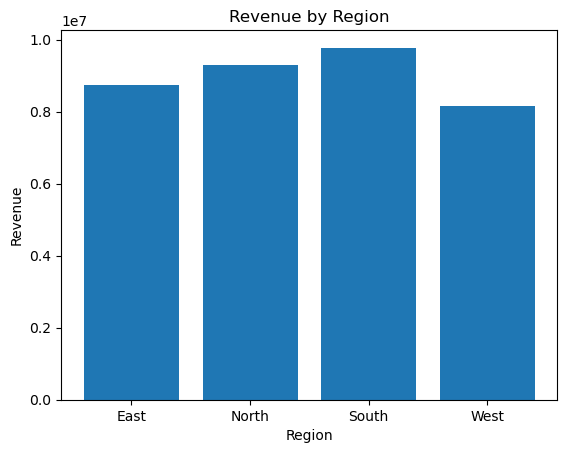

In [85]:
plt.bar(region_by_revenue.index,region_by_revenue.values)
# plt.bar(df["Region"], region_by_revenue.values) --- error
# gives an error because the number of x-values and y-values are different
# df["Region"] contains one value for every row in the dataframe
#| Row | Region |
#| --- | ------ |
#| 0   | East   |
#| 1   | West   |
#| 2   | East   |
#| 3   | North  |
#| 4   | West   |
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()
# Here y values aren't reflecting

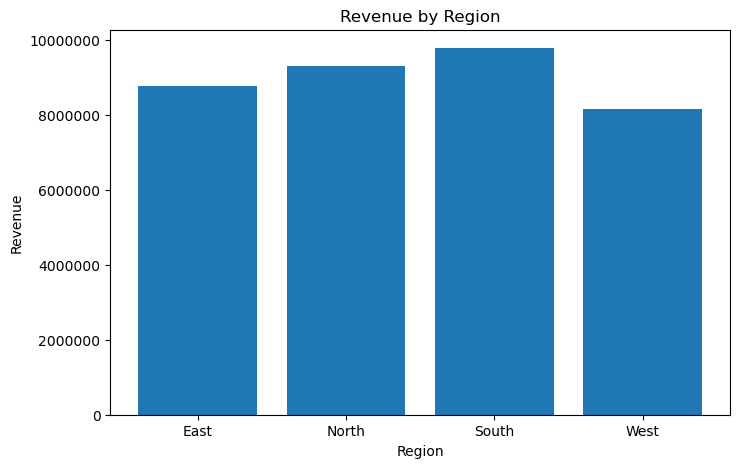

In [83]:
plt.figure(figsize=(8,5))
plt.bar(region_by_revenue.index, region_by_revenue.values)
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [90]:
# Revenue by Product
revune_by_product = df.groupby("Product")["Revenue"].sum()
print(revune_by_product)

Product
Headphones    7938161.5
Laptop        6278944.0
Monitor       7490278.0
Phone         7582090.0
Tablet        6668128.5
Name: Revenue, dtype: float64


Text(0.5, 1.0, 'Revenue by Product')

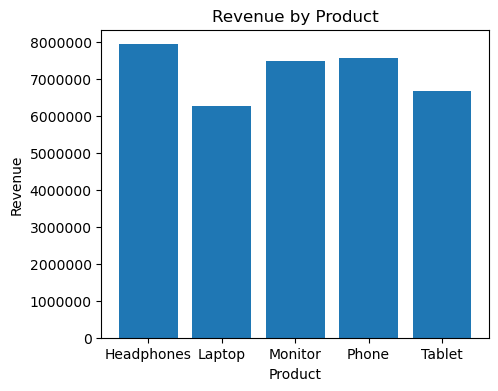

In [94]:
#bargraph
plt.figure(figsize=(5,4))
plt.bar(revune_by_product.index, revune_by_product.values)
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.ticklabel_format(style='plain', axis='y') #control how numbers appear on the axis
plt.title("Revenue by Product")
# ticklabel_format - changes how numbers appear on axis
# style='plain'- show normal numbers
# axis='y' - apply this to Y-axis

In [100]:
# Monthly Revenue Trend
revenue_by_month = df.groupby("Month_Name")["Revenue"].sum()
print(revenue_by_month)

Month_Name
April        3450988.0
August       3796615.5
December     2618568.5
February     3296627.5
January      2844117.5
July         2634717.5
June         3067053.5
March        2166477.0
May          3267360.5
November     2640851.5
October      3171327.0
September    3002898.0
Name: Revenue, dtype: float64


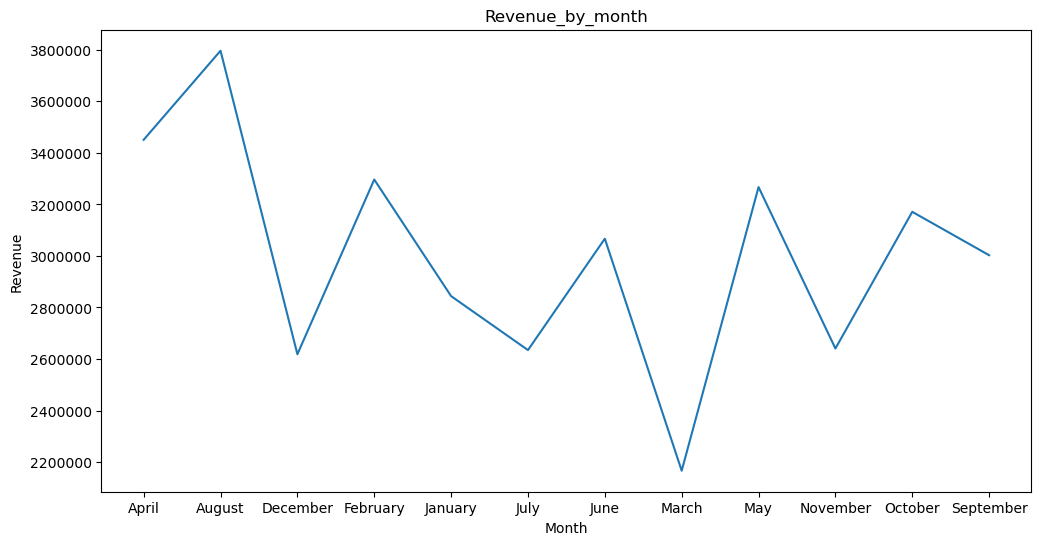

In [107]:
plt.figure(figsize=(12,6))
plt.plot(revenue_by_month.index, revenue_by_month.values)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Revenue_by_month")
plt.ticklabel_format(style='plain',axis='y')

# Below all chatgpt

<Axes: >

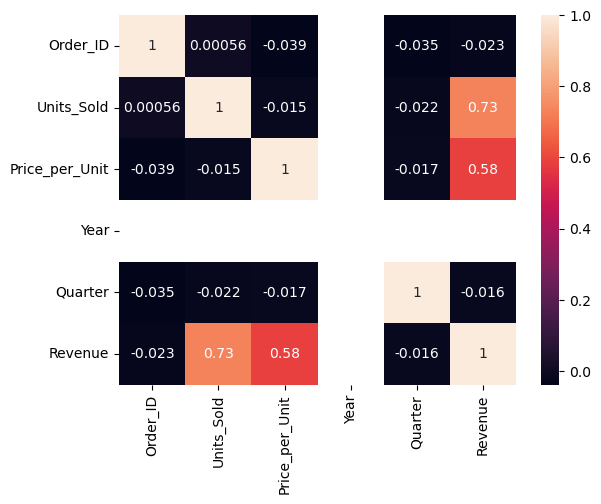

In [110]:
# Region vs Product
# Heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

In [111]:
#| Region/Product | Laptop  | Monitor   | Tablet    | Headphones |
#| -------------- | ------- | --------- | --------- | ---------- |
#| East           | 🔴 High | 🟡 Medium | 🟡 Medium | 🔵 Low     |
#| West           | 🔴 High | 🔴 High   | 🟡 Medium | 🟡 Medium  |

In [112]:
pivot_table = df.pivot_table(values="Revenue",
                             index="Region",
                             columns="Product",
                             aggfunc="sum")

In [115]:
print(pivot_table)

Product  Headphones     Laptop    Monitor      Phone     Tablet
Region                                                         
East      2203502.5  1507563.5  1979750.0  1650362.0  1407041.5
North     1937103.5  1669586.0  1936580.0  2211646.0  1527247.0
South     2423322.0  1889551.0  1926105.0  1706804.0  1826575.0
West      1374233.5  1212243.5  1647843.0  2013278.0  1907265.0


In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(pivot_table,
            annot=True,
            cmap="coolwarm",
            fmt=".0f")

# cmap = color map
# .0f" means: 0 → number of decimal places f → floating number format
# 34567 instead 34567.45
# Without (Annotation)annot=True -- You only see colors, not the numbers.

plt.title("Revenue by Region and Product")
plt.xlabel("Product")
plt.ylabel("Region")

plt.show()
# Rows → Region
# Columns → Product
# Color → Revenue value

In [119]:
# Top 10 Orders by Revenue****
top10_revenue = df.sort_values("Revenue", ascending=False).head(10)
print(top10_revenue)

     Order_ID       Date Region     Product  Units_Sold  Price_per_Unit  Year  \
568      1569 2023-04-10  North  Headphones        24.0          4985.0  2023   
4        1005 2023-03-13  South      Laptop        24.0          4924.0  2023   
694      1695 2023-11-12   East      Laptop        24.0          4900.0  2023   
958      1959 2023-08-31  South       Phone        24.0          4891.0  2023   
448      1449 2023-10-17  North      Laptop        24.0          4810.0  2023   
47       1048 2023-10-01   West  Headphones        24.0          4766.0  2023   
54       1055 2023-02-22  North     Monitor        23.0          4714.0  2023   
418      1419 2023-09-19  South       Phone        22.0          4908.0  2023   
753      1754 2023-03-26  North     Monitor        23.0          4635.0  2023   
474      1475 2023-08-06  South  Headphones        21.0          4998.0  2023   

    Month_Name  Quarter   Revenue  
568      April        2  119640.0  
4        March        1  118176.0  


In [127]:
print(top10_revenue[["Order_ID","Region","Product","Revenue"]])

     Order_ID Region     Product   Revenue
568      1569  North  Headphones  119640.0
4        1005  South      Laptop  118176.0
694      1695   East      Laptop  117600.0
958      1959  South       Phone  117384.0
448      1449  North      Laptop  115440.0
47       1048   West  Headphones  114384.0
54       1055  North     Monitor  108422.0
418      1419  South       Phone  107976.0
753      1754  North     Monitor  106605.0
474      1475  South  Headphones  104958.0


In [128]:
# Average Units Sold per Product
df.groupby("Product")["Units_Sold"].mean()

Product
Headphones    12.315315
Laptop        11.822917
Monitor       12.376190
Phone         13.284314
Tablet        13.482558
Name: Units_Sold, dtype: float64

In [124]:
# Region with Highest Average Revenue
df.groupby("Region")["Revenue"].mean()

Region
East     34172.732422
North    34895.347744
South    38933.693227
West     35924.506608
Name: Revenue, dtype: float64

In [125]:
df.groupby("Region")["Revenue"].mean().max()

38933.69322709164